# 🏢 Twinergy — AI-Driven Digital Twin for Building Energy Forecasting & Anomaly Detection

**Project:** Twinergy  
**Dataset:** ASHRAE Great Energy Predictor III (Kaggle)  
**Notebook covers:** Dataset download → EDA → Preprocessing → Feature Engineering → Model Training → Anomaly Detection

---


## STEP 1: Unzipping the Data



In [4]:
import os
import zipfile

# Dataset is already mounted on Kaggle — no download needed
ASHRAE_PATH = '/kaggle/input/competitions/ashrae-energy-prediction'

# Verify files are there
for f in os.listdir(ASHRAE_PATH):
    size = os.path.getsize(f'{ASHRAE_PATH}/{f}') / 1024 / 1024
    print(f'✅ {f} — {size:.1f} MB')

✅ sample_submission.csv — 426.8 MB
✅ building_metadata.csv — 0.0 MB
✅ weather_train.csv — 7.1 MB
✅ weather_test.csv — 14.1 MB
✅ train.csv — 647.2 MB
✅ test.csv — 1394.7 MB


## STEP 2 — Load the Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette('Blues_r')

print('⏳ Loading datasets...')
train    = pd.read_csv('/kaggle/input/competitions/ashrae-energy-prediction/train.csv', parse_dates=['timestamp'])
building = pd.read_csv('/kaggle/input/competitions/ashrae-energy-prediction/building_metadata.csv')
weather  = pd.read_csv('/kaggle/input/competitions/ashrae-energy-prediction/weather_train.csv', parse_dates=['timestamp'])

print(f'✅ train.csv         — {train.shape[0]:,} rows, {train.shape[1]} columns')
print(f'✅ building_metadata — {building.shape[0]:,} buildings')
print(f'✅ weather_train     — {weather.shape[0]:,} rows')
print(f'\nMonths in data: {sorted(train["timestamp"].dt.month.unique())}')

⏳ Loading datasets...
✅ train.csv         — 20,216,100 rows, 4 columns
✅ building_metadata — 1,449 buildings
✅ weather_train     — 139,773 rows

Months in data: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


In [6]:
print('=== TRAIN (meter readings) ===')
display(train.head(3))
print('\n=== BUILDING METADATA ===')
display(building.head(3))
print('\n=== WEATHER ===')
display(weather.head(3))

=== TRAIN (meter readings) ===


,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01,0.0
1,1,0,2016-01-01,0.0
2,2,0,2016-01-01,0.0



=== BUILDING METADATA ===


,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN



=== WEATHER ===


,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0


## STEP 3 — Exploratory Data Analysis (EDA)
### 3.1 — Basic Stats

In [7]:
print('📊 DATASET OVERVIEW')
print('='*50)
print(f'Date range     : {train.timestamp.min()} → {train.timestamp.max()}')
print(f'Total buildings: {train.building_id.nunique()}')
print(f'Total readings : {len(train):,}')
print(f'Meter types    : {sorted(train.meter.unique())}  (0=elec, 1=chilled water, 2=steam, 3=hot water)')
print(f'\nMissing values in train:')
print(train.isnull().sum())
print(f'\nMissing values in weather:')
print(weather.isnull().sum())

📊 DATASET OVERVIEW
Date range     : 2016-01-01 00:00:00 → 2016-12-31 23:00:00
Total buildings: 1449
Total readings : 20,216,100
Meter types    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  (0=elec, 1=chilled water, 2=steam, 3=hot water)

Missing values in train:
building_id      0
meter            0
timestamp        0
meter_reading    0
dtype: int64

Missing values in weather:
site_id                   0
timestamp                 0
air_temperature          55
cloud_coverage        69173
dew_temperature         113
precip_depth_1_hr     50289
sea_level_pressure    10618
wind_direction         6268
wind_speed              304
dtype: int64


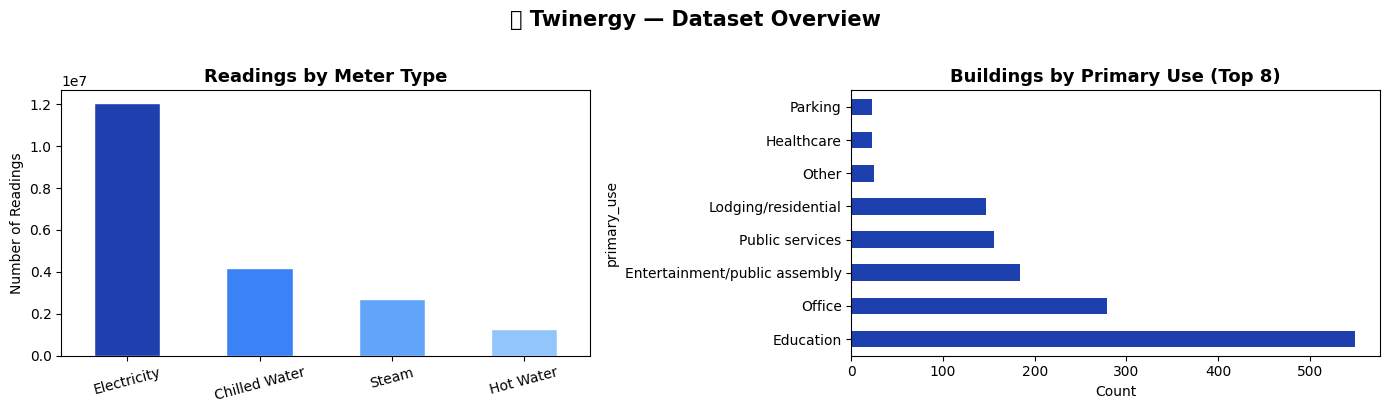

✅ Saved: plot_overview.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

meter_labels = {0: 'Electricity', 1: 'Chilled Water', 2: 'Steam', 3: 'Hot Water'}
meter_counts = train['meter'].value_counts().rename(index=meter_labels)
meter_counts.plot(kind='bar', ax=axes[0], color=['#1E40AF','#3B82F6','#60A5FA','#93C5FD'], edgecolor='white')
axes[0].set_title('Readings by Meter Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Readings')
axes[0].tick_params(axis='x', rotation=15)

building['primary_use'].value_counts().head(8).plot(kind='barh', ax=axes[1], color='#1E40AF')
axes[1].set_title('Buildings by Primary Use (Top 8)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('🏢 Twinergy — Dataset Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/plot_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot_overview.png')

### 3.2 — Energy Consumption Over Time

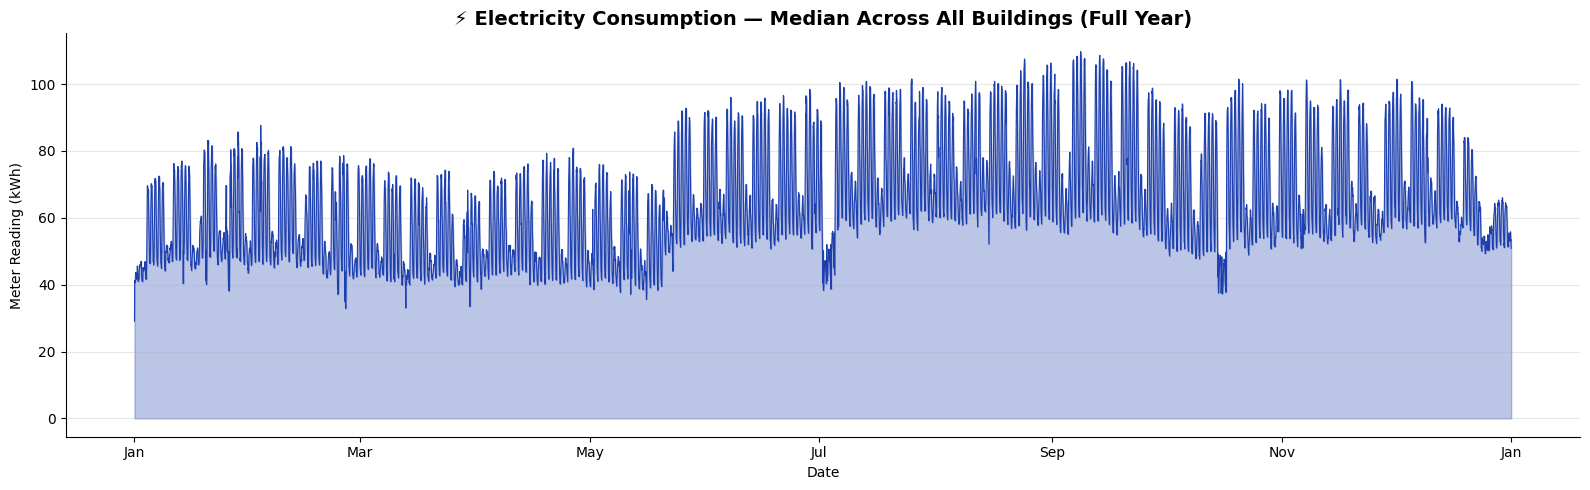

✅ Saved: plot_consumption_yearly.png


In [9]:
elec = train[train['meter'] == 0].copy()
hourly = elec.groupby('timestamp')['meter_reading'].median().reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(hourly['timestamp'], hourly['meter_reading'], alpha=0.3, color='#1E40AF')
ax.plot(hourly['timestamp'], hourly['meter_reading'], color='#1E40AF', linewidth=0.8)
ax.set_title('⚡ Electricity Consumption — Median Across All Buildings (Full Year)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Meter Reading (kWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('/content/plot_consumption_yearly.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot_consumption_yearly.png')

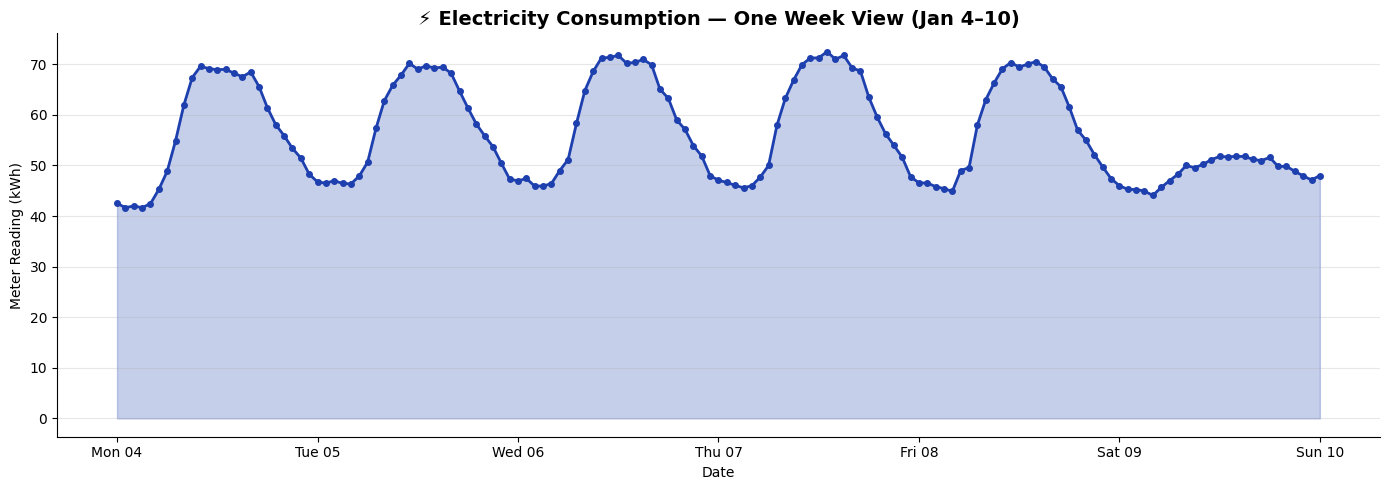

✅ Saved: plot_one_week.png  ← shows weekday vs weekend dip


In [10]:
one_week = hourly[(hourly['timestamp'] >= '2016-01-04') & (hourly['timestamp'] <= '2016-01-10')]

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(one_week['timestamp'], one_week['meter_reading'], alpha=0.25, color='#1E40AF')
ax.plot(one_week['timestamp'], one_week['meter_reading'], color='#1E40AF', linewidth=2, marker='o', markersize=4)
ax.set_title('⚡ Electricity Consumption — One Week View (Jan 4–10)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Meter Reading (kWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('/content/plot_one_week.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot_one_week.png  ← shows weekday vs weekend dip')

### 3.3 — Hourly, Daily & Monthly Patterns

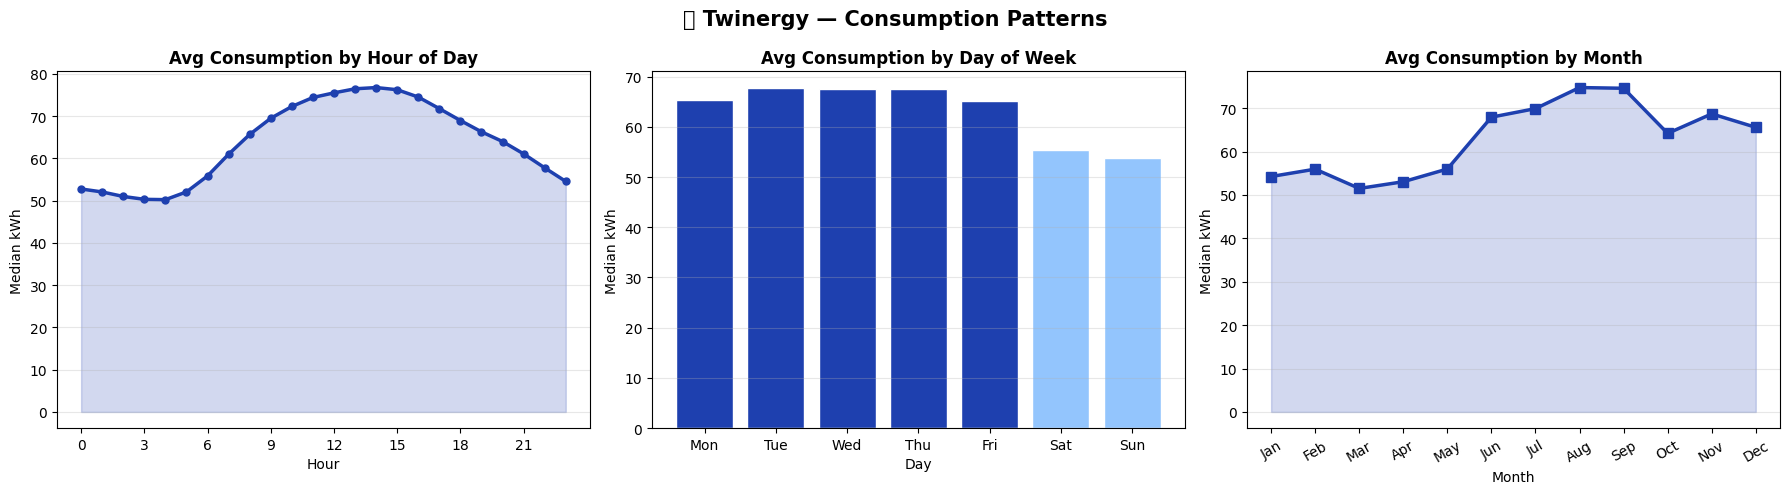

✅ Saved: plot_patterns.png


In [11]:
elec['hour']      = elec['timestamp'].dt.hour
elec['dayofweek'] = elec['timestamp'].dt.dayofweek
elec['month']     = elec['timestamp'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hourly_avg = elec.groupby('hour')['meter_reading'].median()
axes[0].plot(hourly_avg.index, hourly_avg.values, color='#1E40AF', linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.2, color='#1E40AF')
axes[0].set_title('Avg Consumption by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Median kWh')
axes[0].set_xticks(range(0, 24, 3))
axes[0].grid(axis='y', alpha=0.3)

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_avg = elec.groupby('dayofweek')['meter_reading'].median()
colors = ['#1E40AF']*5 + ['#93C5FD']*2
axes[1].bar(day_names, daily_avg.values, color=colors, edgecolor='white')
axes[1].set_title('Avg Consumption by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Median kWh')
axes[1].grid(axis='y', alpha=0.3)

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = elec.groupby('month')['meter_reading'].median()
axes[2].plot(monthly_avg.index, monthly_avg.values, color='#1E40AF', linewidth=2.5, marker='s', markersize=7)
axes[2].fill_between(monthly_avg.index, monthly_avg.values, alpha=0.2, color='#1E40AF')
axes[2].set_title('Avg Consumption by Month', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Median kWh')
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(month_names, rotation=30)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('🏢 Twinergy — Consumption Patterns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/plot_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot_patterns.png')

## STEP 4 — Merge All Three Datasets

In [12]:
print('🔗 Merging datasets...')
df = train.merge(building, on='building_id', how='left')
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.merge(weather, on=['site_id', 'timestamp'], how='left')
print(f'✅ Merged dataframe shape: {df.shape}')
print(f'   Columns: {list(df.columns)}')
display(df.head(3))

🔗 Merging datasets...
✅ Merged dataframe shape: (20216100, 16)
   Columns: ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0


## STEP 5 — Data Cleaning

In [13]:
print(f'Shape before cleaning: {df.shape}')

df = df[df['meter_reading'] > 0]
print(f'After removing zero/negative readings: {df.shape}')

def remove_outliers(group):
    upper = group['meter_reading'].quantile(0.999)
    return group[group['meter_reading'] <= upper]

df = df.groupby('meter', group_keys=False).apply(remove_outliers)
print(f'After removing extreme outliers (99.9th percentile): {df.shape}')

weather_cols = ['air_temperature', 'dew_temperature', 'wind_speed', 'sea_level_pressure']
df[weather_cols] = df.groupby('site_id')[weather_cols].transform(
    lambda x: x.ffill().bfill()
)
print(f'Missing weather values after fill:')
print(df[weather_cols].isnull().sum())

df['meter_reading_log'] = np.log1p(df['meter_reading'])
print(f'\n✅ Cleaning done. Final shape: {df.shape}')

Shape before cleaning: (20216100, 16)
After removing zero/negative readings: (18342124, 16)
After removing extreme outliers (99.9th percentile): (18323781, 16)
Missing weather values after fill:
air_temperature            0
dew_temperature            0
wind_speed                 0
sea_level_pressure    773753
dtype: int64

✅ Cleaning done. Final shape: (18323781, 17)


## STEP 6 — Feature Engineering


In [14]:
print('⚙️  Building features... (this takes a while, be patient)')

df = df.sort_values(['building_id', 'meter', 'timestamp']).reset_index(drop=True)

# Time features
df['hour']               = df['timestamp'].dt.hour
df['dayofweek']          = df['timestamp'].dt.dayofweek
df['month']              = df['timestamp'].dt.month
df['dayofyear']          = df['timestamp'].dt.dayofyear
df['is_weekend']         = (df['dayofweek'] >= 5).astype(int)
df['is_business_hours']  = ((df['hour'] >= 8) & (df['hour'] <= 18) & (df['is_weekend'] == 0)).astype(int)
df['hour_sin']           = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']           = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin']          = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']          = np.cos(2 * np.pi * df['month'] / 12)
print('✅ Time features done')

# Lag features
group = df.groupby(['building_id', 'meter'])['meter_reading_log']
df['lag_1hr']   = group.shift(1)
df['lag_24hr']  = group.shift(24)
df['lag_168hr'] = group.shift(168)
print('✅ Lag features done')

# Rolling stats
df['rolling_mean_6hr']   = group.transform(lambda x: x.shift(1).rolling(6,   min_periods=1).mean())
df['rolling_mean_24hr']  = group.transform(lambda x: x.shift(1).rolling(24,  min_periods=1).mean())
df['rolling_std_24hr']   = group.transform(lambda x: x.shift(1).rolling(24,  min_periods=1).std())
df['rolling_mean_168hr'] = group.transform(lambda x: x.shift(1).rolling(168, min_periods=1).mean())
print('✅ Rolling stats done')

# Weather interaction
df['temp_x_hour']    = df['air_temperature'] * df['hour']
df['temp_x_weekend'] = df['air_temperature'] * df['is_weekend']
df['occupancy_proxy']= df['is_business_hours'] * df['rolling_mean_6hr']
print('✅ Weather interaction & occupancy proxy done')

print(f'\n📊 Total features: {df.shape[1]} columns | Shape: {df.shape}')

⚙️  Building features... (this takes a while, be patient)
✅ Time features done
✅ Lag features done
✅ Rolling stats done
✅ Weather interaction & occupancy proxy done

📊 Total features: 37 columns | Shape: (18323781, 37)


In [15]:
feature_cols = [
    'hour', 'dayofweek', 'month', 'is_weekend', 'is_business_hours',
    'hour_sin', 'hour_cos', 'lag_1hr', 'lag_24hr', 'lag_168hr',
    'rolling_mean_6hr', 'rolling_std_24hr', 'temp_x_hour', 'occupancy_proxy'
]
print('=== SAMPLE OF ENGINEERED FEATURES ===')
display(df[['timestamp', 'building_id', 'meter_reading'] + feature_cols].dropna().head(5))

=== SAMPLE OF ENGINEERED FEATURES ===


,timestamp,building_id,meter_reading,hour,dayofweek,month,is_weekend,is_business_hours,hour_sin,hour_cos,lag_1hr,lag_24hr,lag_168hr,rolling_mean_6hr,rolling_std_24hr,temp_x_hour,occupancy_proxy
168,2016-05-27 13:00:00,0,181.561,13,4,5,0,1,-0.258819,-0.965926,5.207084,5.243793,3.799613,5.202164,0.057565,332.8,5.202164
169,2016-05-27 14:00:00,0,182.244,14,4,5,0,1,-0.500000,-0.866025,5.207084,5.229267,3.651717,5.188415,0.057183,365.4,5.188415
170,2016-05-27 15:00:00,0,178.831,15,4,5,0,1,-0.707107,-0.707107,5.210819,5.221928,3.980748,5.197998,0.057050,408.0,5.197998
171,2016-05-27 16:00:00,0,176.101,16,4,5,0,1,-0.866025,-0.500000,5.192018,5.247387,4.100703,5.206431,0.057109,480.0,5.206431
172,2016-05-27 17:00:00,0,179.513,17,4,5,0,1,-0.965926,-0.258819,5.176720,5.258105,6.107023,5.201994,0.056861,510.0,5.201994


## STEP 7 — Feature Correlation Heatmap

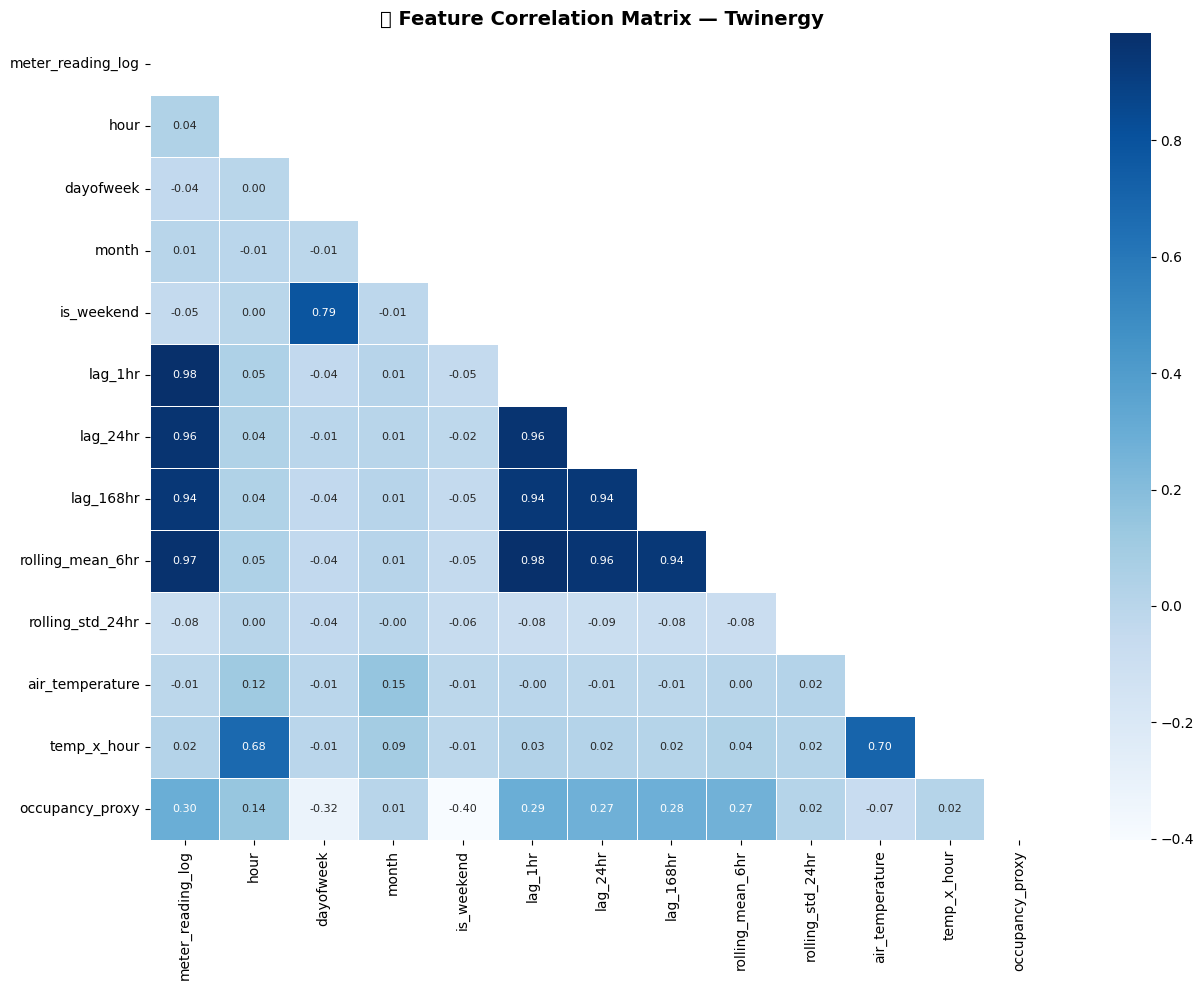

✅ Saved: plot_correlation.png


In [16]:
corr_cols = [
    'meter_reading_log', 'hour', 'dayofweek', 'month', 'is_weekend',
    'lag_1hr', 'lag_24hr', 'lag_168hr',
    'rolling_mean_6hr', 'rolling_std_24hr',
    'air_temperature', 'temp_x_hour', 'occupancy_proxy'
]
corr_df = df[corr_cols].dropna().sample(50000, random_state=42)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='Blues', ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('🔗 Feature Correlation Matrix — Twinergy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/plot_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot_correlation.png')

## STEP 8 — Demo: One Building Baseline vs Actual

In [17]:
BUILDING_ID = 1
METER_TYPE  = 0

demo_building = df[
    (df['building_id'] == BUILDING_ID) & (df['meter'] == METER_TYPE)
].copy().sort_values('timestamp')

print(f'Building {BUILDING_ID} electricity readings: {len(demo_building)}')
print(f'Primary use : {demo_building["primary_use"].iloc[0]}')
print(f'Square feet : {demo_building["square_feet"].iloc[0]:,.0f}')
display(demo_building[['timestamp', 'meter_reading', 'air_temperature', 'hour', 'is_weekend']].head(5))

Building 1 electricity readings: 5547
Primary use : Education
Square feet : 2,720


,timestamp,meter_reading,air_temperature,hour,is_weekend
5411,2016-01-02 13:00:00,35.2201,15.0,13,1
5412,2016-01-05 03:00:00,13.9242,11.1,3,0
5413,2016-01-09 04:00:00,18.5656,16.1,4,1
5414,2016-01-10 15:00:00,23.2070,21.7,15,1
5415,2016-01-12 11:00:00,13.9242,6.1,11,0


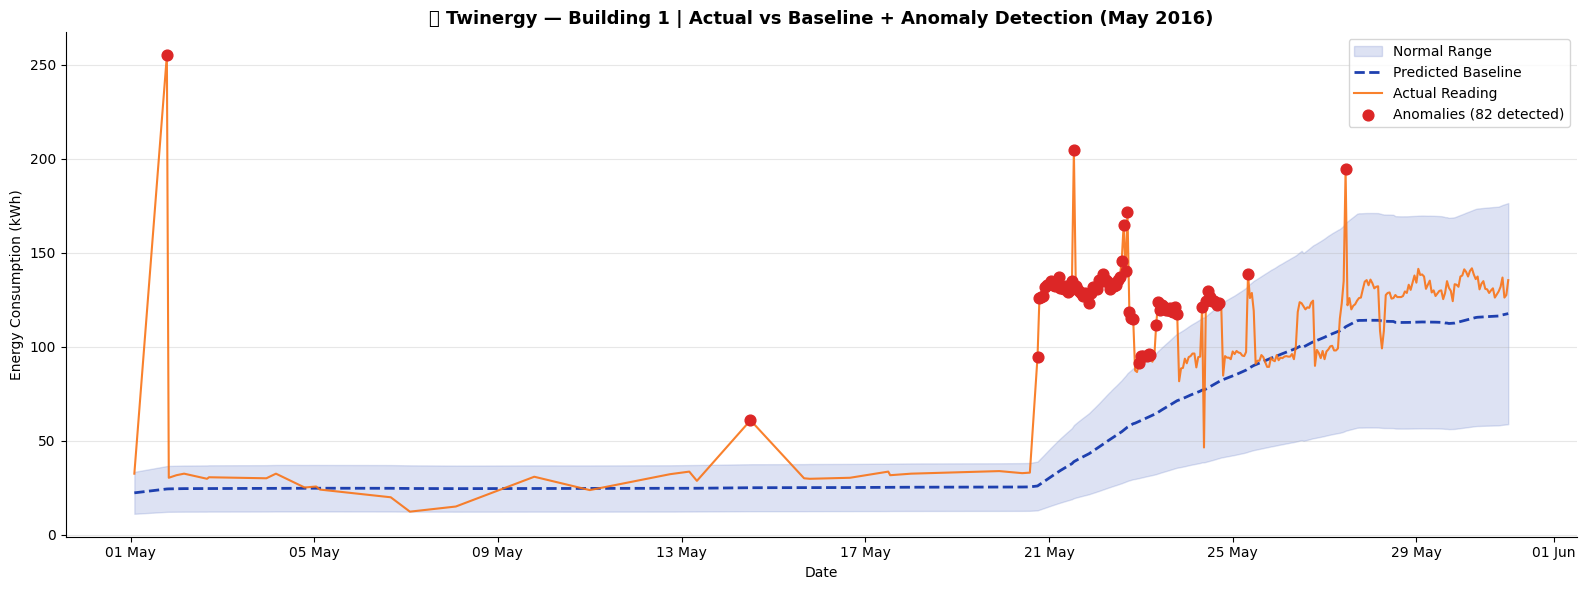

✅ Saved: plot_twinergy_demo.png  ← MONEY SHOT FOR THE REVIEW


In [18]:
demo_building['baseline']   = demo_building['meter_reading'].rolling(24*7, min_periods=1).mean()
demo_building['upper_band'] = demo_building['baseline'] * 1.5
demo_building['lower_band'] = demo_building['baseline'] * 0.5

one_month = demo_building[
    (demo_building['timestamp'] >= '2016-05-01') &
    (demo_building['timestamp'] <= '2016-05-31')
]

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(one_month['timestamp'], one_month['lower_band'], one_month['upper_band'],
                alpha=0.15, color='#1E40AF', label='Normal Range')
ax.plot(one_month['timestamp'], one_month['baseline'],
        color='#1E40AF', linewidth=2, linestyle='--', label='Predicted Baseline')
ax.plot(one_month['timestamp'], one_month['meter_reading'],
        color='#F97316', linewidth=1.5, alpha=0.9, label='Actual Reading')

anomalies = one_month[one_month['meter_reading'] > one_month['upper_band']]
ax.scatter(anomalies['timestamp'], anomalies['meter_reading'],
           color='#DC2626', zorder=5, s=60, label=f'Anomalies ({len(anomalies)} detected)')

ax.set_title(f'🏢 Twinergy — Building {BUILDING_ID} | Actual vs Baseline + Anomaly Detection (May 2016)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (kWh)')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('/content/plot_twinergy_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot_twinergy_demo.png  ← MONEY SHOT FOR THE REVIEW')

## STEP 9 — Save Clean Dataset

In [19]:
# Keep lag_168hr NaNs filled instead of dropped — preserves all 12 months
df_model = df.dropna(subset=['lag_1hr', 'lag_24hr', 'rolling_mean_6hr']).copy()
df_model['lag_168hr'] = df_model['lag_168hr'].fillna(df_model['rolling_mean_24hr'])

print(f'Shape before dropna: {df.shape}')
print(f'Shape after:         {df_model.shape}')
print(f'\nMonths in clean data:')
print(df_model[df_model['meter']==0]['month'].value_counts().sort_index())


Shape before dropna: (18323781, 37)
Shape after:         (18266719, 37)

Months in clean data:
month
1      905331
2      828205
3      868901
4      915981
5      968645
6      984359
7      998669
8     1009750
9      994087
10    1008029
11     992858
12    1010483
Name: count, dtype: int64


In [22]:
df_model.to_csv('/kaggle/working/twinergy_clean.csv', index=False)
print(f'✅ Saved twinergy_clean.csv')

✅ Saved twinergy_clean.csv


## STEP 10 — Install ML Libraries

In [20]:
!pip install lightgbm shap -q
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import shap, pickle
print('✅ Done')

✅ Done


## STEP 11 — Train/Test Split
Using last 2 months (Nov–Dec) as test set — correct time-series split.

In [21]:
df_elec = df_model[df_model['meter'] == 0].copy()

FEATURES = [
    'hour', 'dayofweek', 'month', 'dayofyear',
    'is_weekend', 'is_business_hours',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'lag_1hr', 'lag_24hr', 'lag_168hr',
    'rolling_mean_6hr', 'rolling_mean_24hr', 'rolling_std_24hr', 'rolling_mean_168hr',
    'temp_x_hour', 'temp_x_weekend', 'occupancy_proxy',
    'air_temperature', 'square_feet'
]
TARGET = 'meter_reading_log'

df_elec['square_feet'] = df_elec['square_feet'].fillna(df_elec['square_feet'].median())

X = df_elec[FEATURES]
y = df_elec[TARGET]

# Last 2 months = test
split_date = '2016-11-01'
train_mask = df_elec['timestamp'] < split_date
test_mask  = df_elec['timestamp'] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'✅ Train: {X_train.shape[0]:,} rows  (Jan–Oct 2016)')
print(f'   Test : {X_test.shape[0]:,} rows  (Nov–Dec 2016)')
print(f'   Features: {len(FEATURES)}')

✅ Train: 9,481,957 rows  (Jan–Oct 2016)
   Test : 2,003,341 rows  (Nov–Dec 2016)
   Features: 22


## STEP 12 — Train LightGBM

In [22]:
params = {
    'objective'        : 'regression',
    'metric'           : 'rmse',
    'learning_rate'    : 0.05,
    'num_leaves'       : 64,
    'min_child_samples': 20,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 1,
    'verbosity'        : -1,
    'random_state'     : 42
}

dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_test,  label=y_test, reference=dtrain)

print('⏳ Training LightGBM...')
model = lgb.train(
    params, dtrain,
    num_boost_round=500,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)
print(f'\n✅ Done. Best iteration: {model.best_iteration}')

⏳ Training LightGBM...
[100]	train's rmse: 0.135085	val's rmse: 0.130068
[200]	train's rmse: 0.128508	val's rmse: 0.125587
[300]	train's rmse: 0.125376	val's rmse: 0.123773
[400]	train's rmse: 0.123083	val's rmse: 0.122594
[500]	train's rmse: 0.121269	val's rmse: 0.121594

✅ Done. Best iteration: 500


## STEP 13 — Evaluate

In [23]:
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred)
mape = mean_absolute_percentage_error(y_test_orig, y_pred_orig) * 100

print('='*45)
print('     TWINERGY — Model Evaluation')
print('='*45)
print(f'  RMSE (log scale)  : {rmse_log:.4f}')
print(f'  MAPE              : {mape:.2f}%')
print(f'  Accuracy proxy    : {100 - mape:.2f}%')
print('='*45)

     TWINERGY — Model Evaluation
  RMSE (log scale)  : 0.1216
  MAPE              : 13.09%
  Accuracy proxy    : 86.91%


## STEP 14 — Forecast Plot

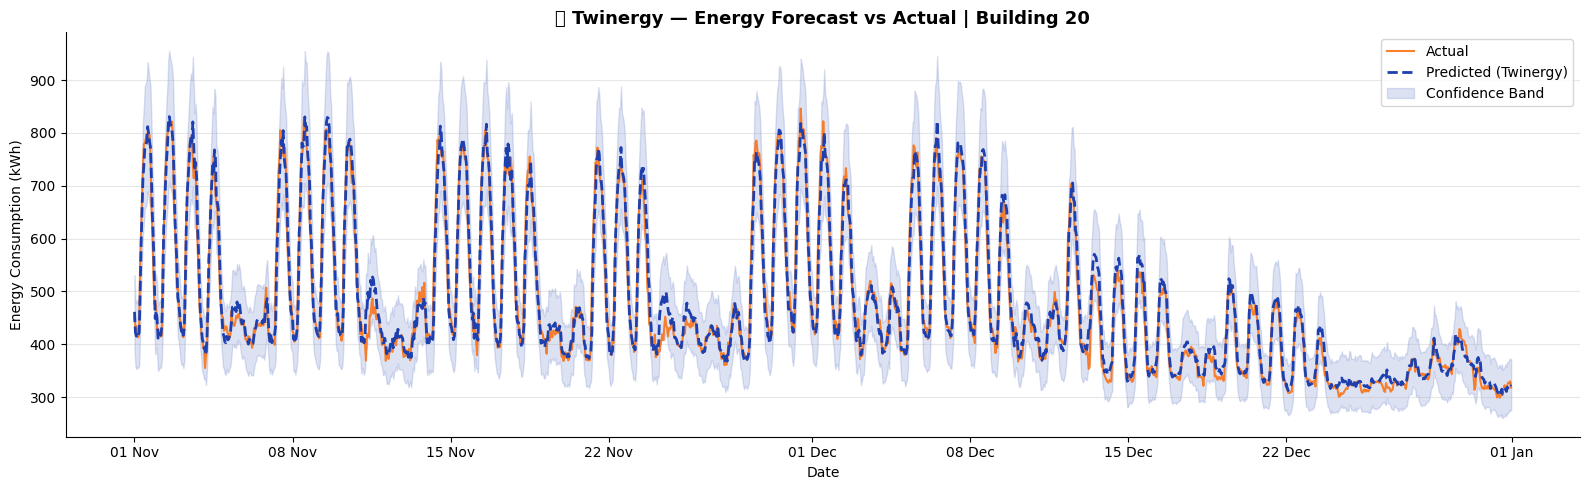

✅ Saved: plot_forecast.png


In [24]:
b_id = 20
b_mask = (df_elec['building_id'] == b_id) & test_mask

actual     = np.expm1(y_test[b_mask])
predicted  = np.expm1(model.predict(X_test[b_mask], num_iteration=model.best_iteration))
timestamps = df_elec[b_mask]['timestamp']

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(timestamps, actual.values, color='#F97316', linewidth=1.5, label='Actual', alpha=0.9)
ax.plot(timestamps, predicted, color='#1E40AF', linewidth=2, label='Predicted (Twinergy)', linestyle='--')
ax.fill_between(timestamps, predicted * 0.85, predicted * 1.15, alpha=0.15, color='#1E40AF', label='Confidence Band')
ax.set_title(f'🏢 Twinergy — Energy Forecast vs Actual | Building {b_id}', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (kWh)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('/content/plot_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot_forecast.png')

## STEP 15 — SHAP Explainability

⏳ Running SHAP (~1 min)...


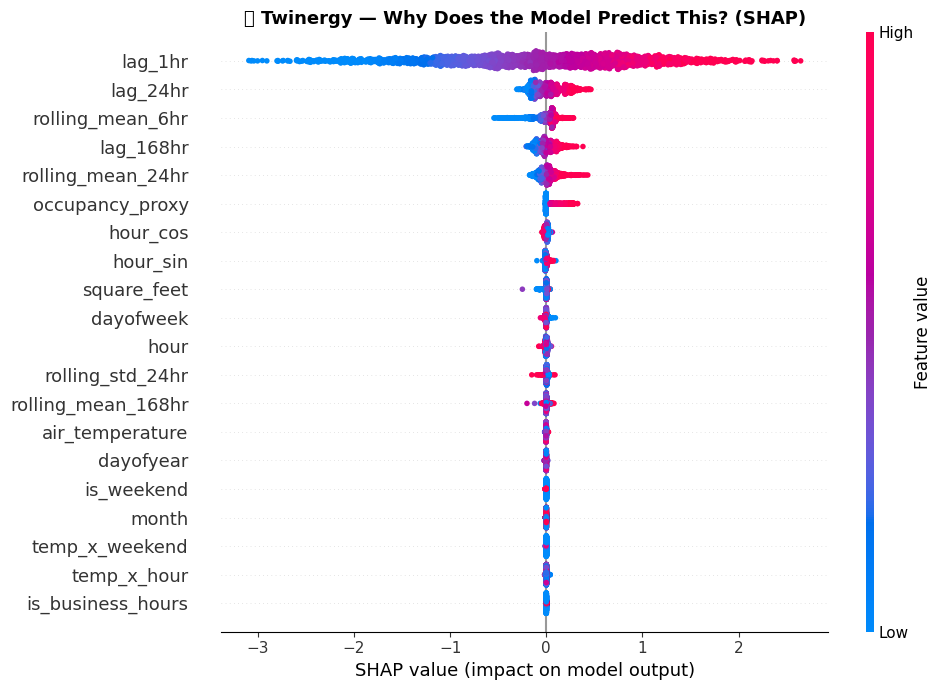

✅ Saved: plot_shap.png


In [25]:
print('⏳ Running SHAP (~1 min)...')
sample_idx  = X_test.sample(2000, random_state=42).index
X_sample    = X_test.loc[sample_idx]
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, show=False, plot_size=(10,7))
plt.title('🔍 Twinergy — Why Does the Model Predict This? (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/plot_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: plot_shap.png')

## STEP 16 — Isolation Forest Anomaly Detection

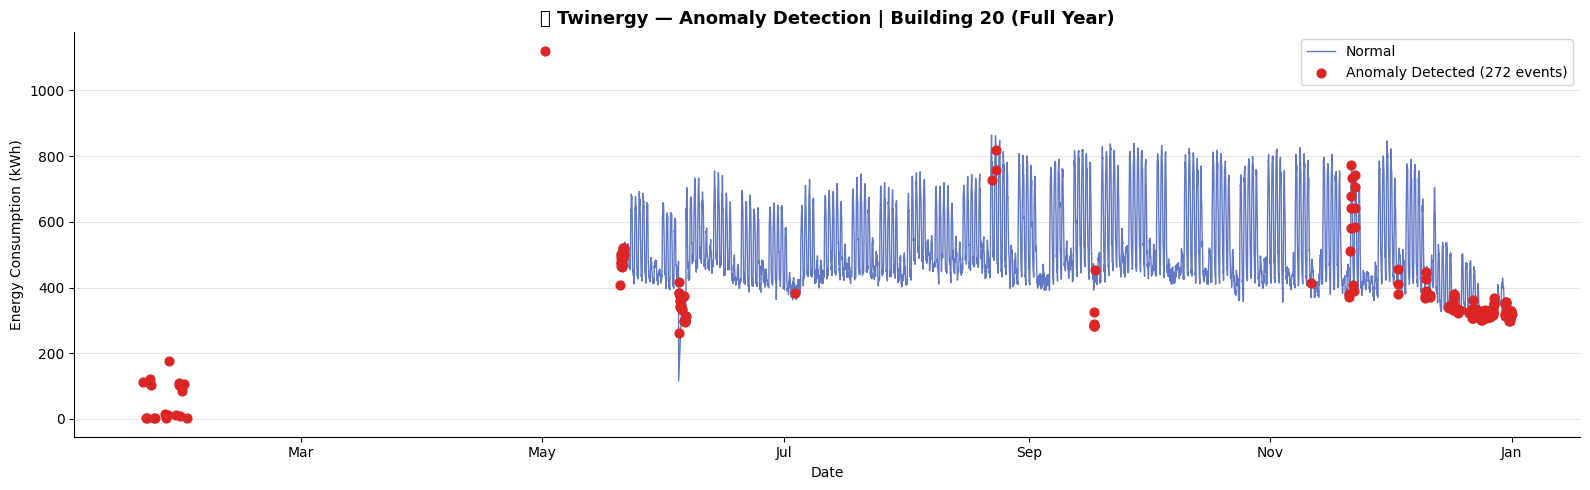

✅ Anomalies detected: 272 out of 5424 (5.0%)
✅ Saved: plot_anomaly.png


In [26]:
from sklearn.ensemble import IsolationForest

ANOMALY_FEATURES = [
    'meter_reading_log', 'rolling_mean_6hr', 'rolling_std_24hr',
    'lag_1hr', 'lag_24hr', 'hour', 'is_weekend', 'air_temperature'
]

b0 = df_elec[df_elec['building_id'] == 20].dropna(subset=ANOMALY_FEATURES).copy()

iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
b0['anomaly_score'] = iso.fit_predict(b0[ANOMALY_FEATURES])
b0['is_anomaly']    = (b0['anomaly_score'] == -1).astype(int)

fig, ax = plt.subplots(figsize=(16, 5))
normal    = b0[b0['is_anomaly'] == 0]
anomalies = b0[b0['is_anomaly'] == 1]
ax.plot(normal['timestamp'], np.expm1(normal['meter_reading_log']),
        color='#1E40AF', linewidth=1, alpha=0.7, label='Normal')
ax.scatter(anomalies['timestamp'], np.expm1(anomalies['meter_reading_log']),
           color='#DC2626', zorder=5, s=40, label=f'Anomaly Detected ({len(anomalies)} events)')
ax.set_title('🚨 Twinergy — Anomaly Detection | Building 20 (Full Year)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (kWh)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('/content/plot_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Anomalies detected: {len(anomalies)} out of {len(b0)} ({len(anomalies)/len(b0)*100:.1f}%)')
print('✅ Saved: plot_anomaly.png')

## STEP 17 — Save Models

In [27]:
import pickle

with open('/kaggle/working/twinergy_lgbm.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('/kaggle/working/twinergy_isoforest.pkl', 'wb') as f:
    pickle.dump(iso, f)

print('   plot_overview.png          — dataset overview')
print('   plot_consumption_yearly.png — full year trend')
print('   plot_one_week.png           — weekday vs weekend')
print('   plot_patterns.png           — hour/day/month patterns')
print('   plot_correlation.png        — feature correlation matrix')
print('   plot_twinergy_demo.png      — baseline vs actual + anomalies')
print('   plot_forecast.png           — LightGBM forecast vs actual')
print('   plot_shap.png               — SHAP explainability')
print('   plot_anomaly.png            — isolation forest anomaly detection')
print('   twinergy_lgbm.pkl           — trained forecasting model')
print('   twinergy_isoforest.pkl      — trained anomaly model')
print('   twinergy_clean.csv          — clean feature-engineered dataset')

   plot_overview.png          — dataset overview
   plot_consumption_yearly.png — full year trend
   plot_one_week.png           — weekday vs weekend
   plot_patterns.png           — hour/day/month patterns
   plot_correlation.png        — feature correlation matrix
   plot_twinergy_demo.png      — baseline vs actual + anomalies
   plot_forecast.png           — LightGBM forecast vs actual
   plot_shap.png               — SHAP explainability
   plot_anomaly.png            — isolation forest anomaly detection
   twinergy_lgbm.pkl           — trained forecasting model
   twinergy_isoforest.pkl      — trained anomaly model
   twinergy_clean.csv          — clean feature-engineered dataset
